<a href="https://colab.research.google.com/github/Aireenelz/WIE3007-DMW-Group6/blob/xgboost-modelling-joan/xgboost_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### 1. Data Loading and Train-Test Split

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Load the preprocessed data
df = pd.read_csv('preprocessed_financial_data.csv')

# Separate features (X) and target (y)
# drop 'LoanDefault' because it's the answer, and 'LoanPurposeDescription' because it's text
X = df.drop(columns=['LoanDefault', 'LoanPurposeDescription', 'CustomerID'], errors='ignore')
y = df['LoanDefault']

# Train-Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 2. XGBoost Modelling

#### 2.1 Underfit XGBoost Model
##### - make the model underfit by setting a very low n_estimators (few trees) and a very shallow max_depth (simple trees)

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score

# Initialize Underfit Model
# Very few trees and very shallow depth -> can't learn complex patterns
model_underfit = xgb.XGBClassifier(
    n_estimators=2,
    max_depth=1,
    learning_rate=0.01,
    random_state=42
)

model_underfit.fit(X_train, y_train)

# Evaluate
train_pred = model_underfit.predict(X_train)
test_pred = model_underfit.predict(X_test)

print("Underfitting Results:")
print(f"Train Accuracy: {accuracy_score(y_train, train_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, test_pred):.4f}")

Underfitting Results:
Train Accuracy: 0.5100
Test Accuracy: 0.4600


#### 2.2 Overfit XGBoost Model
##### - force overfitting by allowing the trees to grow infinitely deep and setting the learning rate high with no regularization

In [ ]:
# Initialize Overfit Model
# Deep trees (max_depth=50) allow the model to memorize every single row
model_overfit = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=50,
    learning_rate=0.5,
    random_state=42
)

model_overfit.fit(X_train, y_train)

# Evaluate
train_pred_ov = model_overfit.predict(X_train)
test_pred_ov = model_overfit.predict(X_test)

print("Overfitting Results:")
print(f"Train Accuracy: {accuracy_score(y_train, train_pred_ov):.4f} ")
print(f"Test Accuracy: {accuracy_score(y_test, test_pred_ov):.4f} ")

Overfitting Results:
Train Accuracy: 1.0000 
Test Accuracy: 0.7300 


#### 2.3 Optimal Fit XGBoost Model
##### - use "early stopping" or balanced parameters to find the best fit

In [ ]:
# Initialize Optimal Model
model_optimal = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8, # Use only 80% of data per tree to prevent memorization
    colsample_bytree=0.8,
    random_state=42
)

model_optimal.fit(X_train, y_train)

# Evaluate
train_pred_opt = model_optimal.predict(X_train)
test_pred_opt = model_optimal.predict(X_test)

print("Optimal Fit Results:")
print(f"Train Accuracy: {accuracy_score(y_train, train_pred_opt):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, test_pred_opt):.4f}")

Optimal Fit Results:
Train Accuracy: 0.9850
Test Accuracy: 0.7450


#### 3. Performance Evaluation and AI Interpretation
#### 3.1 Performance Evaluation
- Accuracy: It tells you how many total loans (Default + Non-Default) were correctly classified. It is your "baseline" metric.

- F1-Score: This is critical because "Default" cases are usually rarer than "Normal" cases. F1-Score ignores the easy-to-predict "Normal" cases and focuses on how well you caught the "Defaults" without being overly sensitive.

- ROC-AUC: This tells you the model's "Separation Power." An AUC of 0.80 means there is an 80% chance that the model will be able to distinguish between a defaulter and a non-defaulter.

- RMSE: Usually used in regression, but in classification, we use it on the probability scores. It measures how "confident" the model was. A high RMSE means the model was "unsure" even when it was right.

Final Model Metrics
Accuracy:  0.7450
F1-Score:  0.7628
ROC-AUC:   0.8418
RMSE:      0.4136


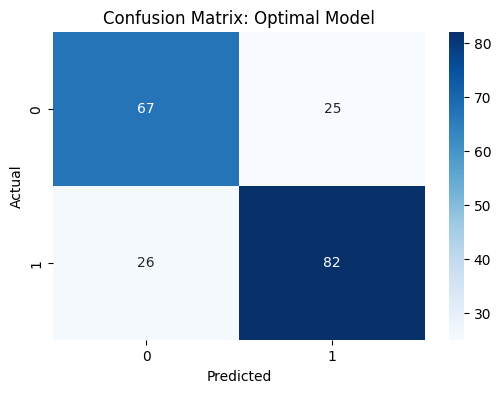

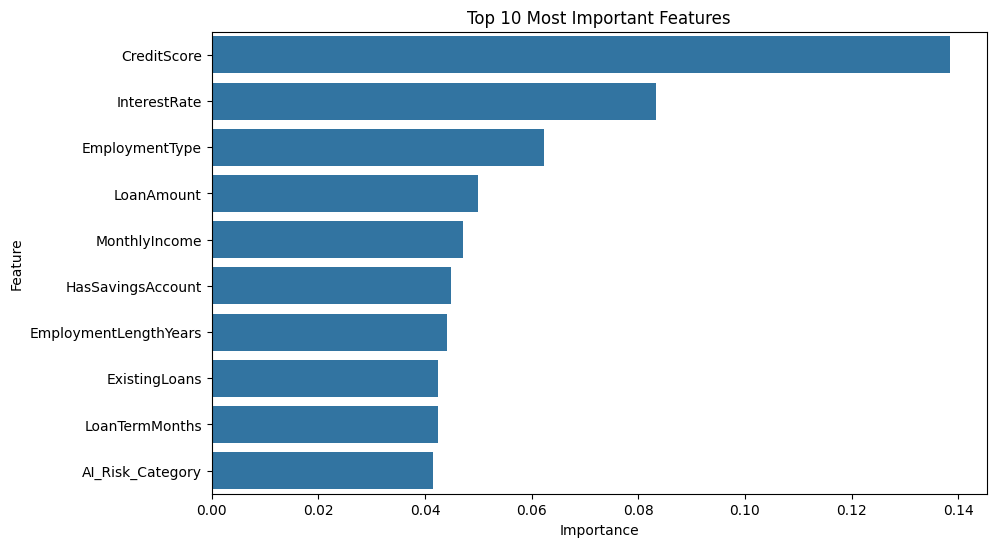

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    mean_squared_error, confusion_matrix, roc_curve
)
import numpy as np

# Get Predictions and Probabilities
y_pred = model_optimal.predict(X_test)
y_probs = model_optimal.predict_proba(X_test)[:, 1] # Probability of 'Default'

# Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)
rmse = np.sqrt(mean_squared_error(y_test, y_probs)) # RMSE of probabilities

print(f"Final Model Metrics")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"RMSE:      {rmse:.4f}")

# Visualization: Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Optimal Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance
importances = model_optimal.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Most Important Features')
plt.show()

#### 3.2 AI Interpretation
#####- use lightweight DistillGPT2 model to interpret feature importance and generate a summary


In [ ]:
from transformers import pipeline

# 1. Use a slightly more robust model for explanation (GPT-2)
# We set device=0 to use the GPU (cuda) for speed
summarizer = pipeline("text-generation", model="gpt2", device=0)

# 2. Get the top features dynamically from your dataframe
top_features = feature_importance_df.iloc[:3]['Feature'].tolist()

# 3. Create a more structured prompt
insight_prompt = (
    f"Predicting loan default depends on {top_features[0]}, {top_features[1]}, and {top_features[2]}. "
    f"The reason {top_features[0]} is important is because"
)

# 4. Generate with better settings
# max_new_tokens: gives it room to explain
# temperature: makes it a bit more creative/human-like
explanation = summarizer(
    insight_prompt,
    max_new_tokens=100,
    temperature=0.7,
    pad_token_id=50256
)

print("\n" + "="*30)
print("AI INTERPRETATION OF RESULTS")
print("="*30)
print(explanation[0]['generated_text'])

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0



AI INTERPRETATION OF RESULTS
Predicting loan default depends on CreditScore, InterestRate, and EmploymentType. The reason CreditScore is important is because it helps you understand the size of your loan payments.

CreditScore is a lender rated by the CME. It provides a quick estimate of your loan repayment and how much you owe. It also provides some other important information, like your credit report.

The Bankrate.gov website offers a range of information on loan repayment rates. The Bankrate.gov website provides lenders with information about the most common types of loans, including, credit quality, credit report, and credit quality guarant


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import json

# Paste the path you copied here
notebook_path = '/content/drive/MyDrive/Colab Notebooks/xgboost_modelling.ipynb'

with open(notebook_path, 'r') as f:
    data = json.load(f)

if 'widgets' in data.get('metadata', {}):
    del data['metadata']['widgets']
    print("Success! Metadata cleaned.")

with open(notebook_path, 'w') as f:
    json.dump(data, f)

Success! Metadata cleaned.
